In [1]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import h5py
import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "python_scripts" else Path.cwd().parents[1]
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import load_img_natraster


In [2]:
@dataclass
class Cfg:
    monkey_name: str = "baby1"
    date: str = "240816to26"
    brain_area: str = "AIT"
    new_fs: int = 100

cfg = Cfg()
cfg


Cfg(monkey_name='baby1', date='240816to26', brain_area='AIT', new_fs=100)

In [3]:
rasters_path = Path(paths["data_path"]) / "data" / f"{cfg.monkey_name}_natraster{cfg.date}.mat"

with h5py.File(rasters_path, "r") as f:
    raw_shape = f["natraster"].shape

loaded_shape = (raw_shape[2], raw_shape[1], raw_shape[0])
resampled_shape = (loaded_shape[0], int(loaded_shape[1] * cfg.new_fs / 1000), loaded_shape[2])

print(f"file: {rasters_path}")
print(f"raw MATLAB natraster shape (trials, time, channels): {raw_shape}")
print(f"dataloader shape before resampling (channels, time, trials): {loaded_shape}")
print(f"expected shape after resampling to {cfg.new_fs} Hz: {resampled_shape}")


file: /Users/tizianocausin/metrics_II_local/data/baby1_natraster240816to26.mat
raw MATLAB natraster shape (trials, time, channels): (3210, 1000, 383)
dataloader shape before resampling (channels, time, trials): (383, 1000, 3210)
expected shape after resampling to 100 Hz: (383, 100, 3210)


In [4]:
responses = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
)
responses_arr = responses.get_array()

print(f"full response object: {responses}")
print(f"full response shape (channels, time, trials): {responses_arr.shape}")
print(f"sampling frequency: {responses.fs} Hz")


full response object: <useful_stuff.general_utils.utils.TimeSeries object at 0x1539017f0>
full response shape (channels, time, trials): (383, 100, 3210)
sampling frequency: 100 Hz


In [5]:
area_responses = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)
area_arr = area_responses.get_array()

print(f"{cfg.brain_area} response object: {area_responses}")
print(f"{cfg.brain_area} response shape (channels, time, trials): {area_arr.shape}")
print(f"sampling frequency: {area_responses.fs} Hz")


AIT response object: <useful_stuff.general_utils.utils.TimeSeries object at 0x153436e90>
AIT response shape (channels, time, trials): (63, 100, 3210)
sampling frequency: 100 Hz


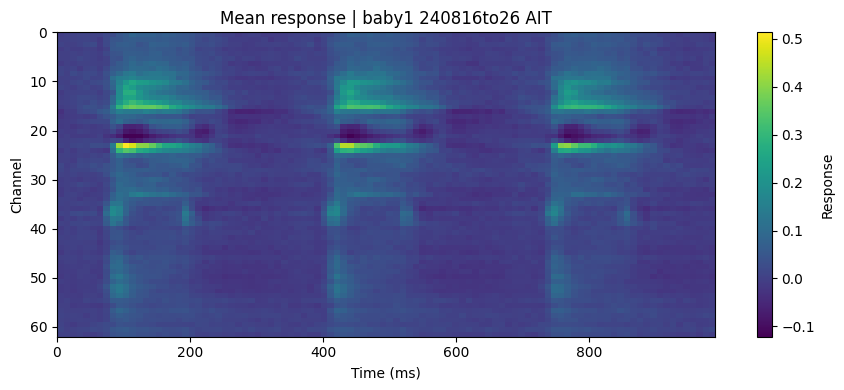

In [6]:
mean_response = area_arr.mean(axis=2)
time_ms = np.arange(mean_response.shape[1]) / cfg.new_fs * 1000

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    mean_response,
    aspect="auto",
    interpolation="nearest",
    extent=[time_ms[0], time_ms[-1], mean_response.shape[0] - 1, 0],
)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"Mean response | {cfg.monkey_name} {cfg.date} {cfg.brain_area}")
fig.colorbar(im, ax=ax, label="Response")
plt.tight_layout()


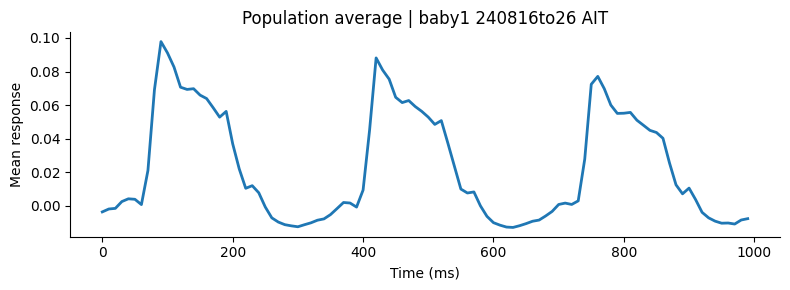

In [7]:
population_timecourse = area_arr.mean(axis=(0, 2))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time_ms, population_timecourse, linewidth=2)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Mean response")
ax.set_title(f"Population average | {cfg.monkey_name} {cfg.date} {cfg.brain_area}")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
